# Data Visualizations

In [2]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import statsmodels.api as sm
import plotly.express as px

In [3]:
df = pd.read_csv("./data/processed/diabetes_food_clean.csv")
df.head()

,CountyID,FoodAccessScore,Urban,SeniorsRate,GroupQuarters,PovertyRatePerc,BlackRate,AsianRate,NHOPIRate,AIANRate,HispanicRate,DiabetesRate,Pop2010,State,County
0,1001,1.410529,0.534460,0.119954,0.008341,0.151376,0.176706,0.008686,0.000586,0.004251,0.024005,0.115555,54571,Alabama,Autauga County
1,1003,0.947357,0.453976,0.167712,0.012653,0.109479,0.093847,0.007396,0.000488,0.006672,0.043848,0.110982,182265,Alabama,Baldwin County
2,1005,1.328587,0.241760,0.142368,0.116296,0.293545,0.468915,0.003897,0.001056,0.004152,0.050515,0.177066,27457,Alabama,Barbour County
3,1007,0.000000,0.000000,0.126816,0.097054,0.138335,0.220249,0.000960,0.000567,0.002793,0.017718,0.131044,22915,Alabama,Bibb County
4,1009,0.245979,0.122989,0.147221,0.008522,0.146238,0.013276,0.002041,0.000663,0.005356,0.080702,0.123109,57322,Alabama,Blount County


# Visualization 1 - Poverty Rate vs Diabetes Rate by State

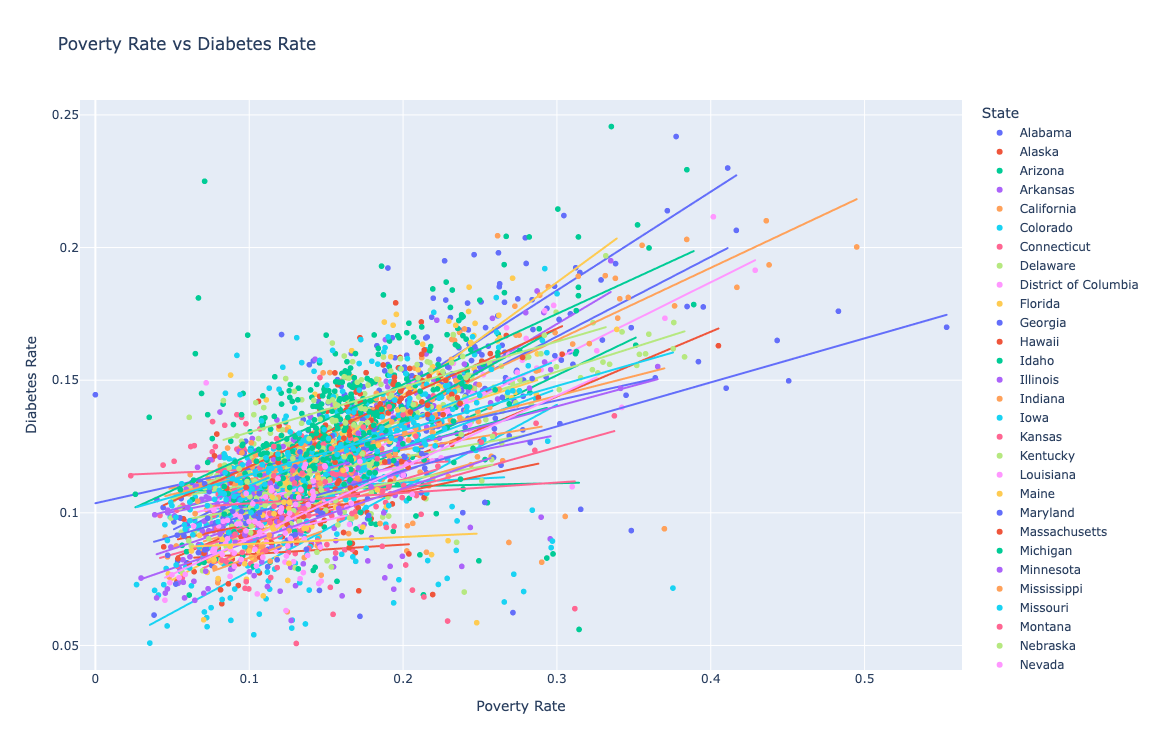

In [4]:
fig = px.scatter(
    df,
    x = "PovertyRatePerc",
    y = "DiabetesRate",
    color = "State",
    hover_data = df.columns,
    trendline = "ols",
    title = "Poverty Rate vs Diabetes Rate",
    labels = {
        'PovertyRatePerc': 'Poverty Rate',
        'DiabetesRate': 'Diabetes Rate'
    },
    height = 750
)

x_min = df["PovertyRatePerc"].min()
x_max = df["PovertyRatePerc"].max()

y_min = df["DiabetesRate"].min()
y_max = df["DiabetesRate"].max()

fig.update_xaxes(range = [x_min - 0.01, x_max + 0.01])
fig.update_yaxes(range = [y_min - 0.01, y_max + 0.01])

fig.show()

# Visualization 2 - Features vs Diabetes Rate

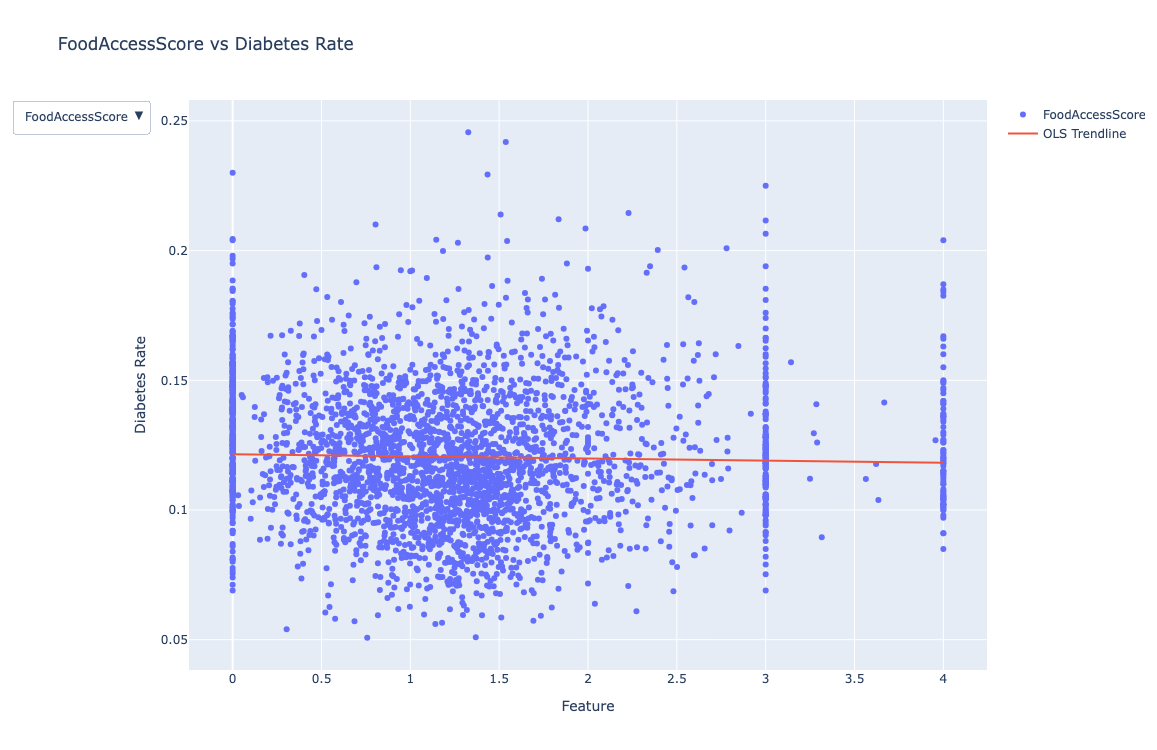

In [6]:
features = [
    "FoodAccessScore",
    "Urban",
    "SeniorsRate",
    "GroupQuarters",
    "PovertyRatePerc",
    "BlackRate",
    "AsianRate",
    "NHOPIRate",
    "AIANRate",
    "HispanicRate"
]

fig = go.Figure()
for i, feature in enumerate(features):

    # Remove missing values
    temp = df[[feature, "DiabetesRate"]].dropna()

    x = temp[feature]
    y = temp["DiabetesRate"]

    # OLS regression
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # Points
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="markers",
            name=feature,
            visible=(i == 0),
            text=df.loc[temp.index, "State"],
            hovertemplate=
                f"{feature}: %{{x}}<br>" +
                "Diabetes Rate: %{y}<br>" +
                "State: %{text}<extra></extra>"
        )
    )

    # Regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.params.iloc[0] + model.params.iloc[1] * x_line

    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode="lines",
            name="OLS Trendline",
            visible=(i == 0),
            hoverinfo="skip"
        )
    )

# Dropdown
buttons = []

for i, feature in enumerate(features):

    visible = [False] * (len(features) * 2)

    # Point trace
    visible[i * 2] = True

    # OLS trace
    visible[i * 2 + 1] = True

    buttons.append(
        dict(
            label=feature,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"{feature} vs Diabetes Rate"}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True
        )
    ],
    xaxis_title="Feature",
    yaxis_title="Diabetes Rate",
    title=f"{features[0]} vs Diabetes Rate",
    height = 750
)

fig.show()

# Visualization 3 - Diabetes Rate Per State

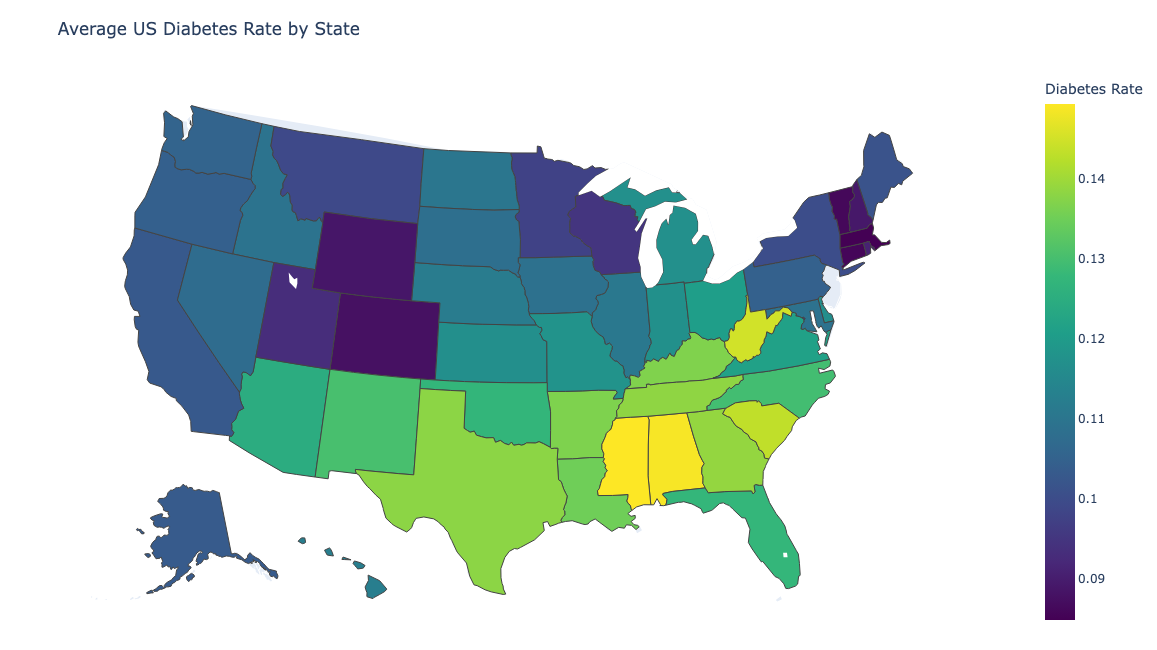

In [7]:
df_state = df.groupby('State')['DiabetesRate'].mean().reset_index()

fig = px.choropleth(
    df_state,
    locations = 'State',
    locationmode = 'USA-states',
    color = 'DiabetesRate',
    scope = 'usa',
    color_continuous_scale = 'Viridis',
    title = 'Average US Diabetes Rate by State',
    labels= {'DiabetesRate': 'Diabetes Rate'},
)

fig.update_layout(
    width = 1000,
    height = 650,
    margin = dict(l = 20, r = 20, t = 70, b = 20)
)

fig.show()